In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Data yang sudah pernah kita bersihkan
df = pd.read_csv('../output/orders_clean.csv',
                 parse_dates=['order_purchase_timestamp'])
df['year'] = df['order_purchase_timestamp'].dt.year

# Dua file baru
products    = pd.read_csv('../data/olist_products_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

# Gabungkan terjemahan ke tabel produk
products = products.merge(translation, on='product_category_name', how='left')

print("Produk total    :", len(products))
print("Kategori unik   :", products['product_category_name_english'].nunique())
products[['product_id','product_category_name_english']].head()

Produk total    : 32951
Kategori unik   : 71


,product_id,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,art
2,96bd76ec8810374ed1b65e291975717f,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,baby
4,9dc1a7de274444849c219cff195d0b71,housewares


In [3]:
# Gabung: orders + items + products (via product_id)
items = pd.read_csv('../data/olist_order_items_dataset.csv')

# df sudah punya product_id dari step 4 — tidak perlu merge items lagi
df_prod = df.merge(
    products[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

df_prod = df_prod.rename(
    columns={'product_category_name_english': 'category'})
df_prod['revenue'] = df_prod['price'] + df_prod['freight_value']

print("Shape final:", df_prod.shape)
print("Kolom:", df_prod.columns.tolist())
print("Contoh kategori:", df_prod['category'].dropna().unique()[:5])

Shape final: (110197, 20)
Kolom: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'year', 'month', 'month_name', 'day_of_week', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'category', 'revenue']
Contoh kategori: ['housewares' 'perfumery' 'auto' 'pet_shop' 'stationery']


Top 10 kategori berdasarkan jumlah order

Pertanyaan: kategori mana yang paling banyak dibeli?

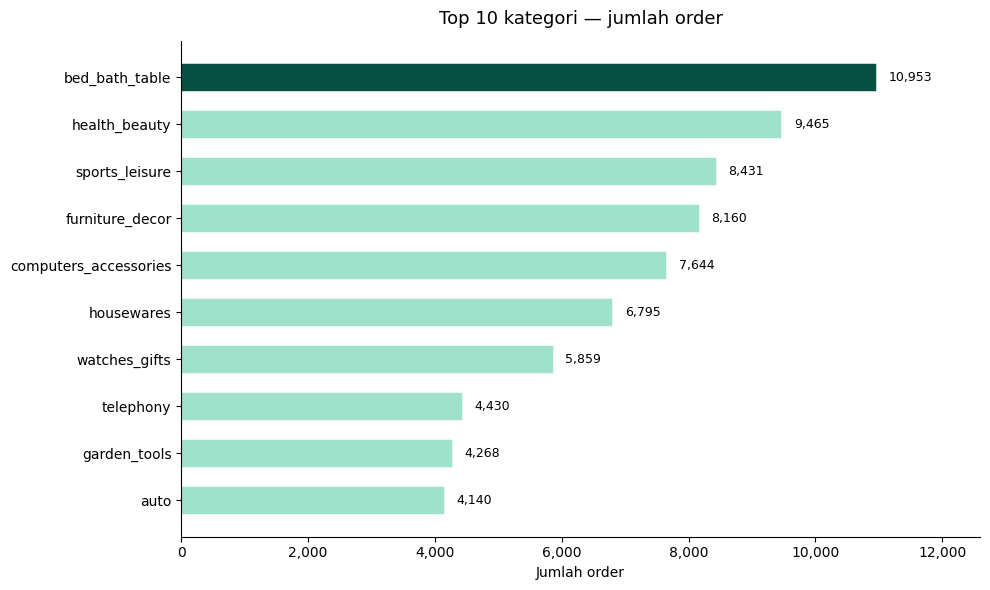

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_count = (df_prod.groupby('category')
               .size()
               .sort_values(ascending=True)
               .tail(10))

colors = ['#9FE1CB'] * 9 + ['#085041']  # highlight #1
bars = ax.barh(top10_count.index, top10_count.values,
               color=colors, height=0.6,
               edgecolor='white', linewidth=0.4)

# Label nilai di ujung bar
for bar, val in zip(bars, top10_count.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_title('Top 10 kategori — jumlah order',
             fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Jumlah order')
ax.set_xlim(0, top10_count.max() * 1.15)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/07-top10-kategori-order.png', dpi=150)
plt.show()

Top 10 kategori berdasarkan total revenue

Pertanyaan: kategori paling laku = paling menguntungkan?

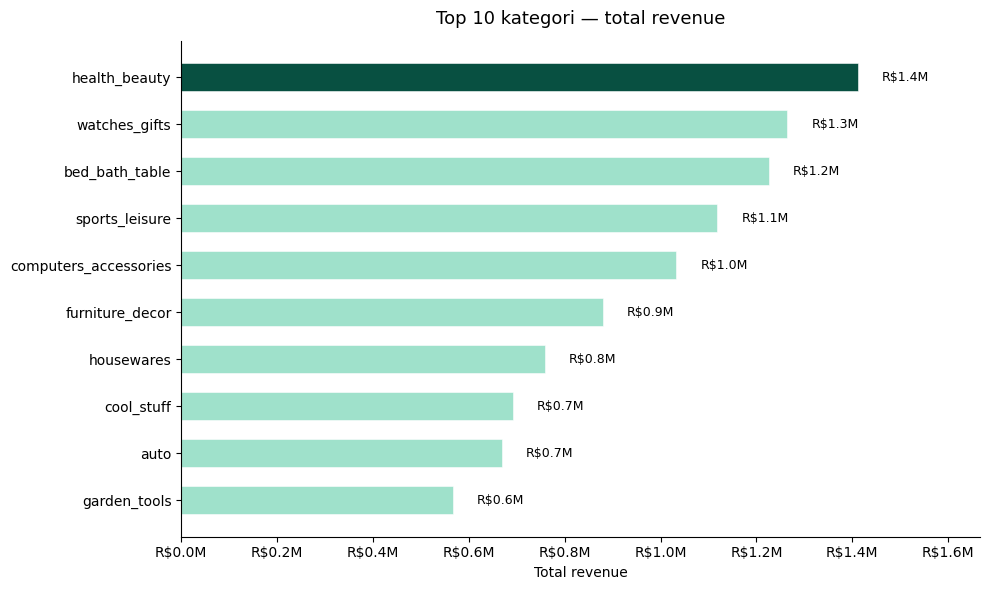

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_rev = (df_prod.groupby('category')['revenue']
             .sum()
             .sort_values(ascending=True)
             .tail(10))

colors_rev = ['#9FE1CB'] * 9 + ['#085041']
bars = ax.barh(top10_rev.index, top10_rev.values,
               color=colors_rev, height=0.6,
               edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, top10_rev.values):
    ax.text(bar.get_width() + 50000,
            bar.get_y() + bar.get_height()/2,
            f'R${val/1e6:.1f}M', va='center', fontsize=9)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))
ax.set_title('Top 10 kategori — total revenue',
             fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Total revenue')
ax.set_xlim(0, top10_rev.max() * 1.18)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/08-top10-kategori-revenue.png', dpi=150)
plt.show()

Rata-rata harga per kategori

Pertanyaan: kategori mana yang jual produk paling mahal?

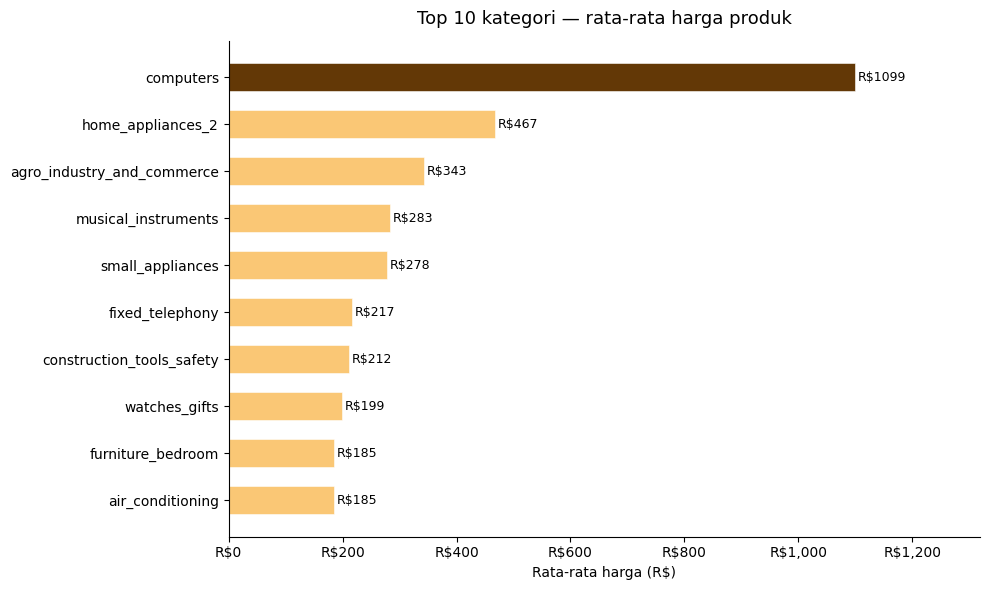

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ambil kategori yang punya minimal 100 transaksi
# supaya rata-ratanya representatif
valid_cats = (df_prod.groupby('category')
              .size()[lambda x: x >= 100].index)

avg_price = (df_prod[df_prod['category'].isin(valid_cats)]
             .groupby('category')['price']
             .mean()
             .sort_values(ascending=True)
             .tail(10))

colors_price = ['#FAC775'] * 9 + ['#633806']
bars = ax.barh(avg_price.index, avg_price.values,
               color=colors_price, height=0.6,
               edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, avg_price.values):
    ax.text(bar.get_width() + 5,
            bar.get_y() + bar.get_height()/2,
            f'R${val:.0f}', va='center', fontsize=9)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${int(x):,}'))
ax.set_title('Top 10 kategori — rata-rata harga produk',
             fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Rata-rata harga (R$)')
ax.set_xlim(0, avg_price.max() * 1.2)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/09-avg-harga-kategori.png', dpi=150)
plt.show()

Tren top 5 kategori dari tahun ke tahun

Pertanyaan: kategori mana yang sedang naik daun?

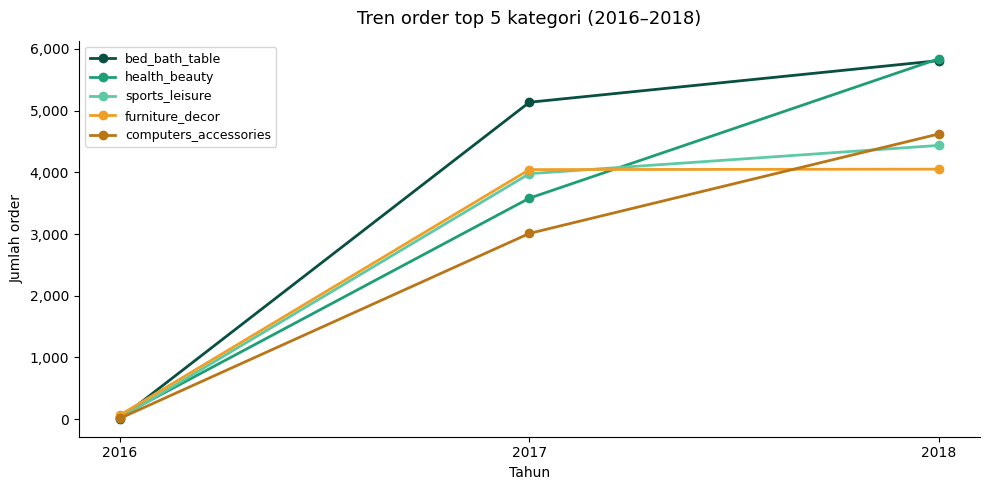

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# Ambil top 5 kategori berdasarkan total order keseluruhan
top5_cats = (df_prod.groupby('category')
             .size()
             .sort_values(ascending=False)
             .head(5).index.tolist())

# Hitung jumlah order per kategori per tahun
trend = (df_prod[df_prod['category'].isin(top5_cats)]
         .groupby(['year','category'])
         .size()
         .reset_index(name='orders'))

# Satu garis per kategori
palette = ['#085041','#1D9E75','#5DCAA5',
           '#EF9F27','#BA7517']

for i, cat in enumerate(top5_cats):
    data = trend[trend['category'] == cat].sort_values('year')
    ax.plot(data['year'], data['orders'],
            marker='o', linewidth=2, markersize=6,
            label=cat, color=palette[i])

ax.set_xticks([2016, 2017, 2018])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_title('Tren order top 5 kategori (2016–2018)',
             fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Tahun')
ax.set_ylabel('Jumlah order')
ax.legend(fontsize=9, loc='upper left')
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/10-tren-kategori-tahunan.png', dpi=150)
plt.show()